# 1 ***Imports***

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf

mpl.rcParams['font.size']=8
mpl.rcParams['figure.dpi']=200


## 2 ***Data***

In [3]:
#Read the data

data=pd.read_csv("gridwatch.csv")


# 3 ***Exploratory Data Analysis***

In [4]:
#First 5 rows 

data.head()

,id,timestamp,demand,coal,nuclear,ccgt,wind,pumped,hydro,biomass,oil,solar,ocgt,french_ict,dutch_ict,irish_ict,nemo,nsl
0,377525,2015-01-01 00:00:04,28809,9079,8049,3360,5251,15,443,1157,0,0.0,0,582,900.0,-72,0,0
1,377526,2015-01-01 00:05:02,28645,8947,8053,3369,5254,0,441,1157,0,0.0,0,586,898.0,-100,0,0
2,377527,2015-01-01 00:10:02,28768,8843,8052,3372,5272,0,440,1157,0,0.0,0,586,898.0,-100,0,0
3,377528,2015-01-01 00:15:02,28917,8763,8047,3339,5303,0,439,1155,0,0.0,0,586,898.0,-100,0,0
4,377529,2015-01-01 00:20:02,28964,8818,8051,3386,5223,0,440,1155,0,0.0,0,586,898.0,-100,0,0


In [5]:
#Data description 

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1154090 entries, 0 to 1154089
Data columns (total 18 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   id           1154090 non-null  int64  
 1    timestamp   1154090 non-null  str    
 2    demand      1154090 non-null  int64  
 3    coal        1154090 non-null  int64  
 4    nuclear     1154090 non-null  int64  
 5    ccgt        1154090 non-null  int64  
 6    wind        1154090 non-null  int64  
 7    pumped      1154090 non-null  int64  
 8    hydro       1154090 non-null  int64  
 9    biomass     1154090 non-null  int64  
 10   oil         1154090 non-null  int64  
 11   solar       1154090 non-null  float64
 12   ocgt        1154090 non-null  int64  
 13   french_ict  1154090 non-null  int64  
 14   dutch_ict   1154090 non-null  float64
 15   irish_ict   1154090 non-null  int64  
 16   nemo        1154090 non-null  int64  
 17   nsl         1154090 non-null  int64  
dtypes: float64(2)

In [6]:
#Clean column names

print(data.columns)
renamed_columns={}
for i in data.columns:
    renamed_columns[i]=i.strip()
data.rename(columns=renamed_columns,inplace=True)
print(data.columns)



Index(['id', ' timestamp', ' demand', ' coal', ' nuclear', ' ccgt', ' wind',
       ' pumped', ' hydro', ' biomass', ' oil', ' solar', ' ocgt',
       ' french_ict', ' dutch_ict', ' irish_ict', ' nemo', ' nsl'],
      dtype='str')
Index(['id', 'timestamp', 'demand', 'coal', 'nuclear', 'ccgt', 'wind',
       'pumped', 'hydro', 'biomass', 'oil', 'solar', 'ocgt', 'french_ict',
       'dutch_ict', 'irish_ict', 'nemo', 'nsl'],
      dtype='str')


In [7]:
#Search for NaNs

for i in data.columns:
    print(f"{i}: {data[i].isnull().sum()}")


id: 0
timestamp: 0
demand: 0
coal: 0
nuclear: 0
ccgt: 0
wind: 0
pumped: 0
hydro: 0
biomass: 0
oil: 0
solar: 0
ocgt: 0
french_ict: 0
dutch_ict: 0
irish_ict: 0
nemo: 0
nsl: 0


In [8]:
#Convert 'timestamp' to type datetime
months={1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
def month(x):
    return months[x]

#Make columns for year-month,month,year
data['timestamp']=pd.to_datetime(data['timestamp'])
year_month=data['timestamp'].dt.strftime('%Y-%m') #Year-month format
Year=[i.year for i in data['timestamp']]
Month=[i.month for i in data['timestamp']]
data.insert(2,'year-month',year_month)
data.insert(3,'year',Year)
data.insert(4,'month',Month)
data.insert(5,'month_name',data['month'].apply(month))
data["renewable"]=data["wind"]+data["solar"]+data["hydro"]+data["biomass"] #Add renewable column
data["fossil"] = data["coal"] +data["ccgt"] +data["ocgt"] +data["oil"] #Add fossil fuel column
data['net_imports']=data['french_ict']+data['irish_ict']+data['nemo']+data['nsl'] #Add column for net imports

data.head()

,id,timestamp,year-month,year,month,month_name,demand,coal,nuclear,ccgt,...,solar,ocgt,french_ict,dutch_ict,irish_ict,nemo,nsl,renewable,fossil,net_imports
0,377525,2015-01-01 00:00:04,2015-01,2015,1,Jan,28809,9079,8049,3360,...,0.0,0,582,900.0,-72,0,0,6851.0,12439,510
1,377526,2015-01-01 00:05:02,2015-01,2015,1,Jan,28645,8947,8053,3369,...,0.0,0,586,898.0,-100,0,0,6852.0,12316,486
2,377527,2015-01-01 00:10:02,2015-01,2015,1,Jan,28768,8843,8052,3372,...,0.0,0,586,898.0,-100,0,0,6869.0,12215,486
3,377528,2015-01-01 00:15:02,2015-01,2015,1,Jan,28917,8763,8047,3339,...,0.0,0,586,898.0,-100,0,0,6897.0,12102,486
4,377529,2015-01-01 00:20:02,2015-01,2015,1,Jan,28964,8818,8051,3386,...,0.0,0,586,898.0,-100,0,0,6818.0,12204,486


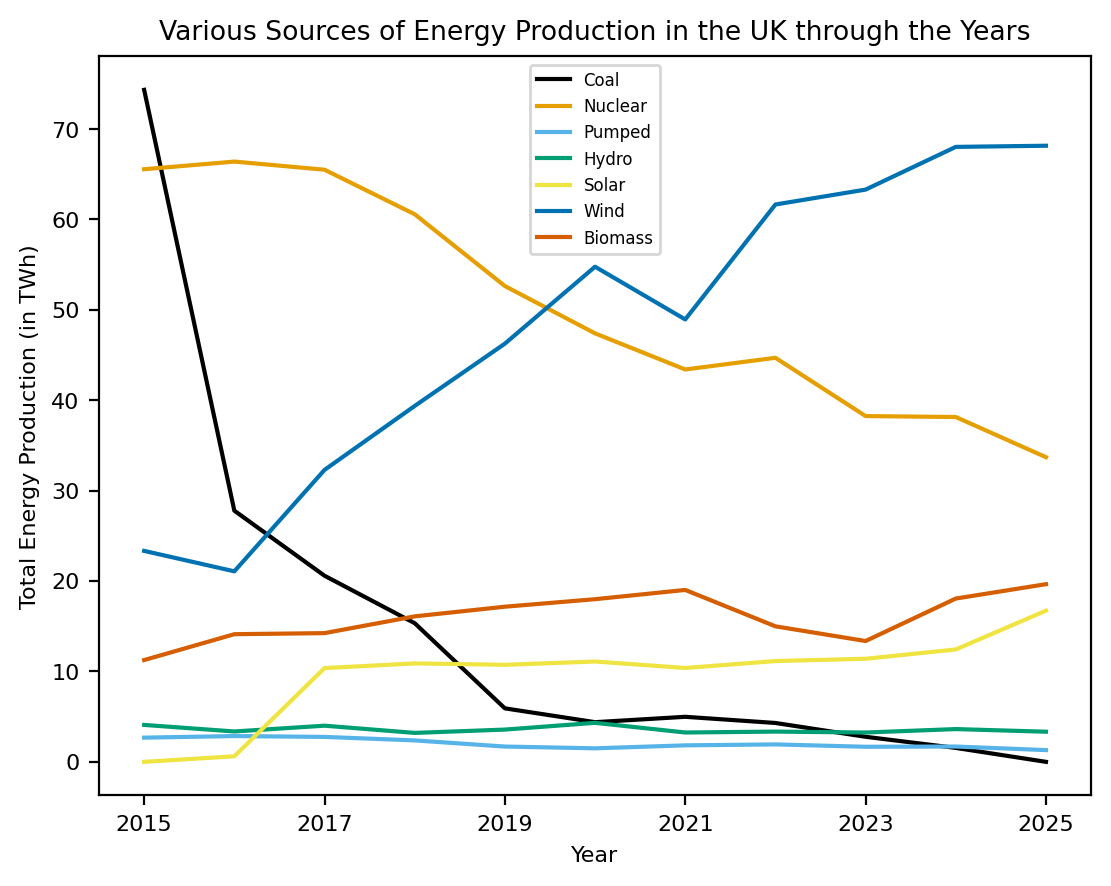

In [9]:
#Plot total energy production for various sources
groups=data.groupby('year')

y1=groups['coal'].sum() * (5/60)/1e6  #Convert to TWh (since data is in 5 minute intervals)
y2=groups['nuclear'].sum() * (5/60)/1e6
y3=groups['pumped'].sum() * (5/60)/1e6
y4=groups['hydro'].sum() * (5/60)/1e6
y5=groups['solar'].sum() * (5/60)/1e6
y6=groups['wind'].sum() * (5/60)/1e6
y7=groups['biomass'].sum() * (5/60)/1e6

x=y1.index

colors = ['#000000','#E69F00','#56B4E9','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7'] #Wong (2011) suggested colour-blind friendly palette

fig,ax=plt.subplots()
ax.plot(x,y1,label='Coal',color=colors[0])
ax.plot(x,y2,label='Nuclear',color=colors[1])
ax.plot(x,y3,label='Pumped',color=colors[2])
ax.plot(x,y4,label='Hydro',color=colors[3])
ax.plot(x,y5,label='Solar',color=colors[4])
ax.plot(x,y6,label='Wind',color=colors[5])
ax.plot(x,y7,label='Biomass',color=colors[6])
plt.title("Various Sources of Energy Production in the UK through the Years")
plt.xticks(ticks=range(2015,2026,2))
plt.xlabel("Year")
plt.ylabel("Total Energy Production (in TWh)")
plt.legend(fontsize=6,loc='best');

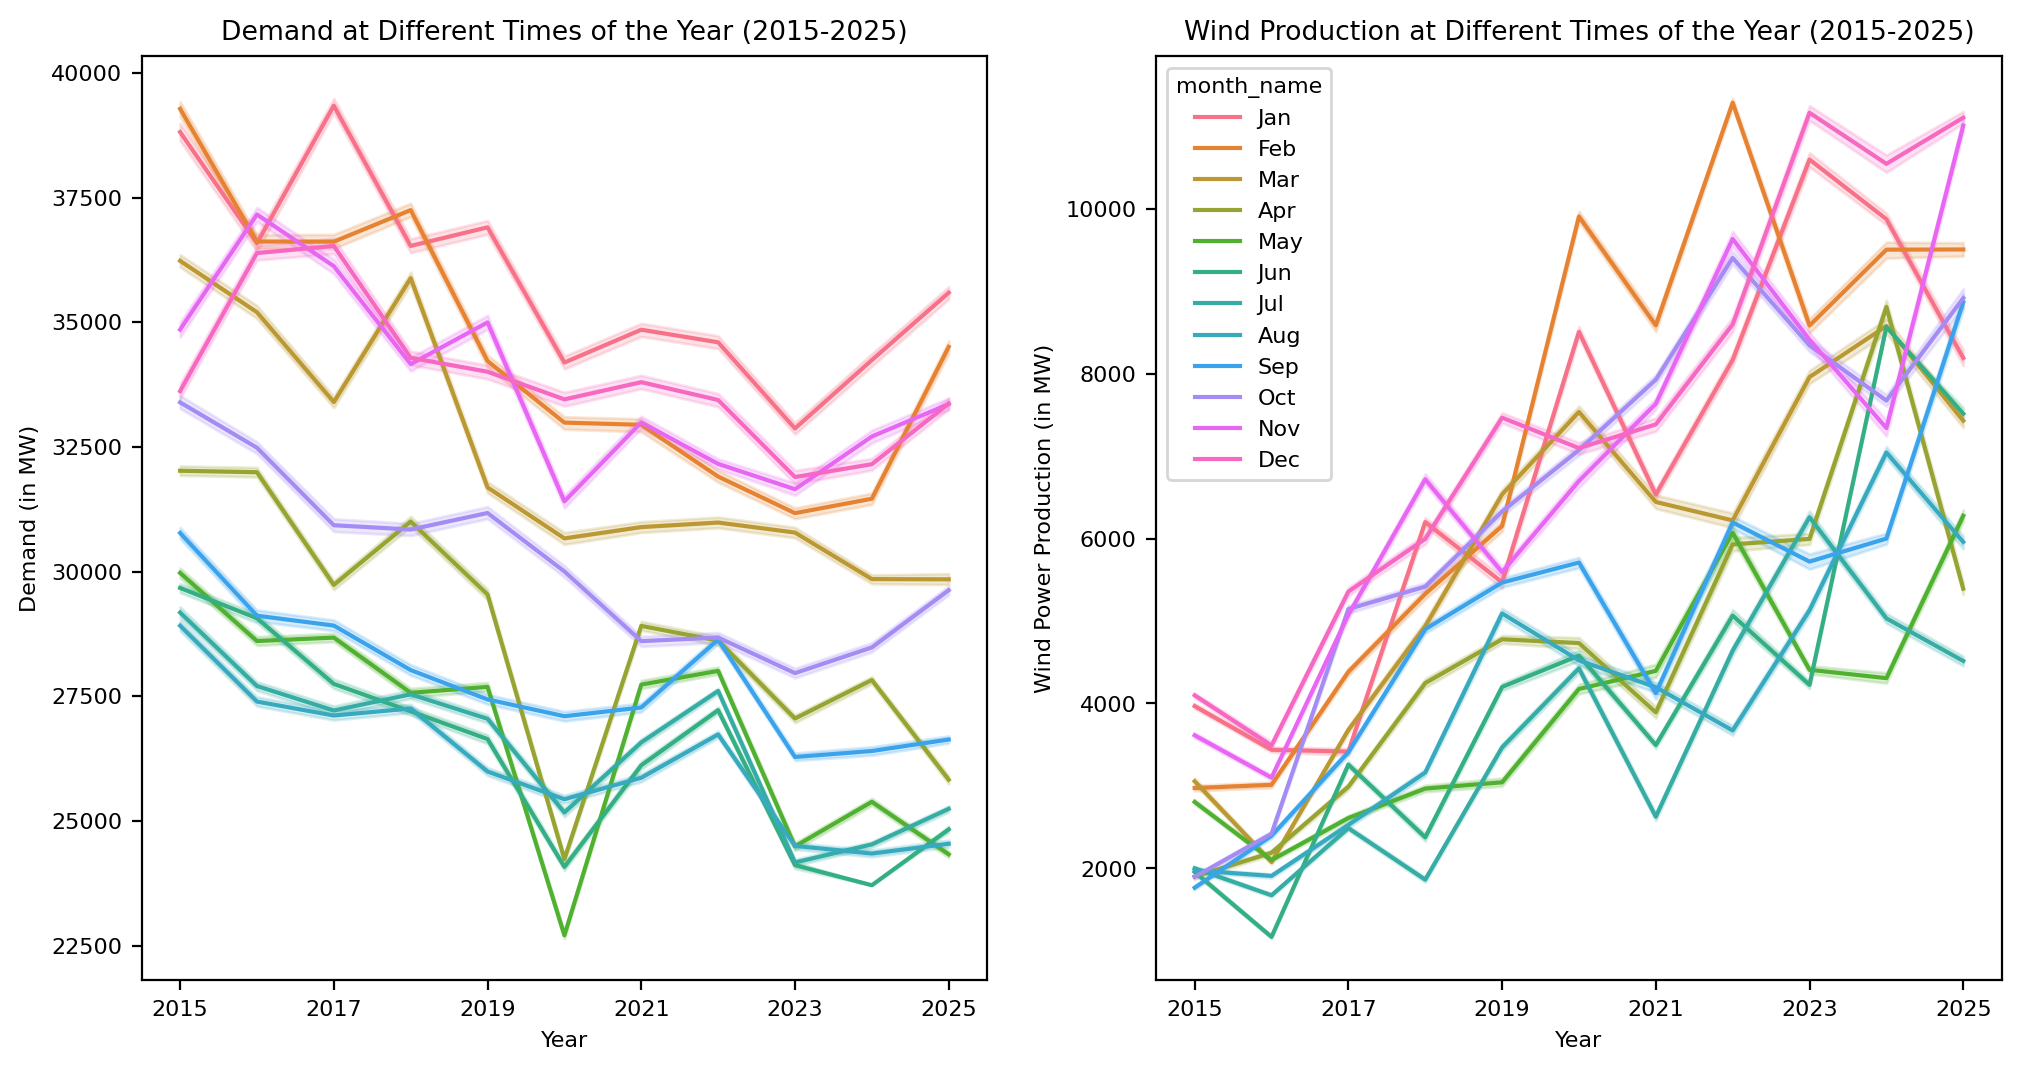

In [10]:
#Plot Demand and Wind at various times of the year

month_order=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig,axes=plt.subplots(1,2,figsize=(12,6))
sns.lineplot(data=data,x="year",y="demand",hue="month_name",hue_order=month_order,ax=axes[0],legend=False)
axes[0].set_title("Demand at Different Times of the Year (2015-2025)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Demand (in MW)")
axes[0].set_xticks(range(2015,2026,2)) #Set x-ticks from 2015-2025 skipping every other year

sns.lineplot(data=data,x="year",y="wind",hue="month_name",hue_order=month_order,ax=axes[1])
axes[1].set_title("Wind Production at Different Times of the Year (2015-2025)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Wind Power Production (in MW)")
axes[1].set_xticks(range(2015,2026,2));




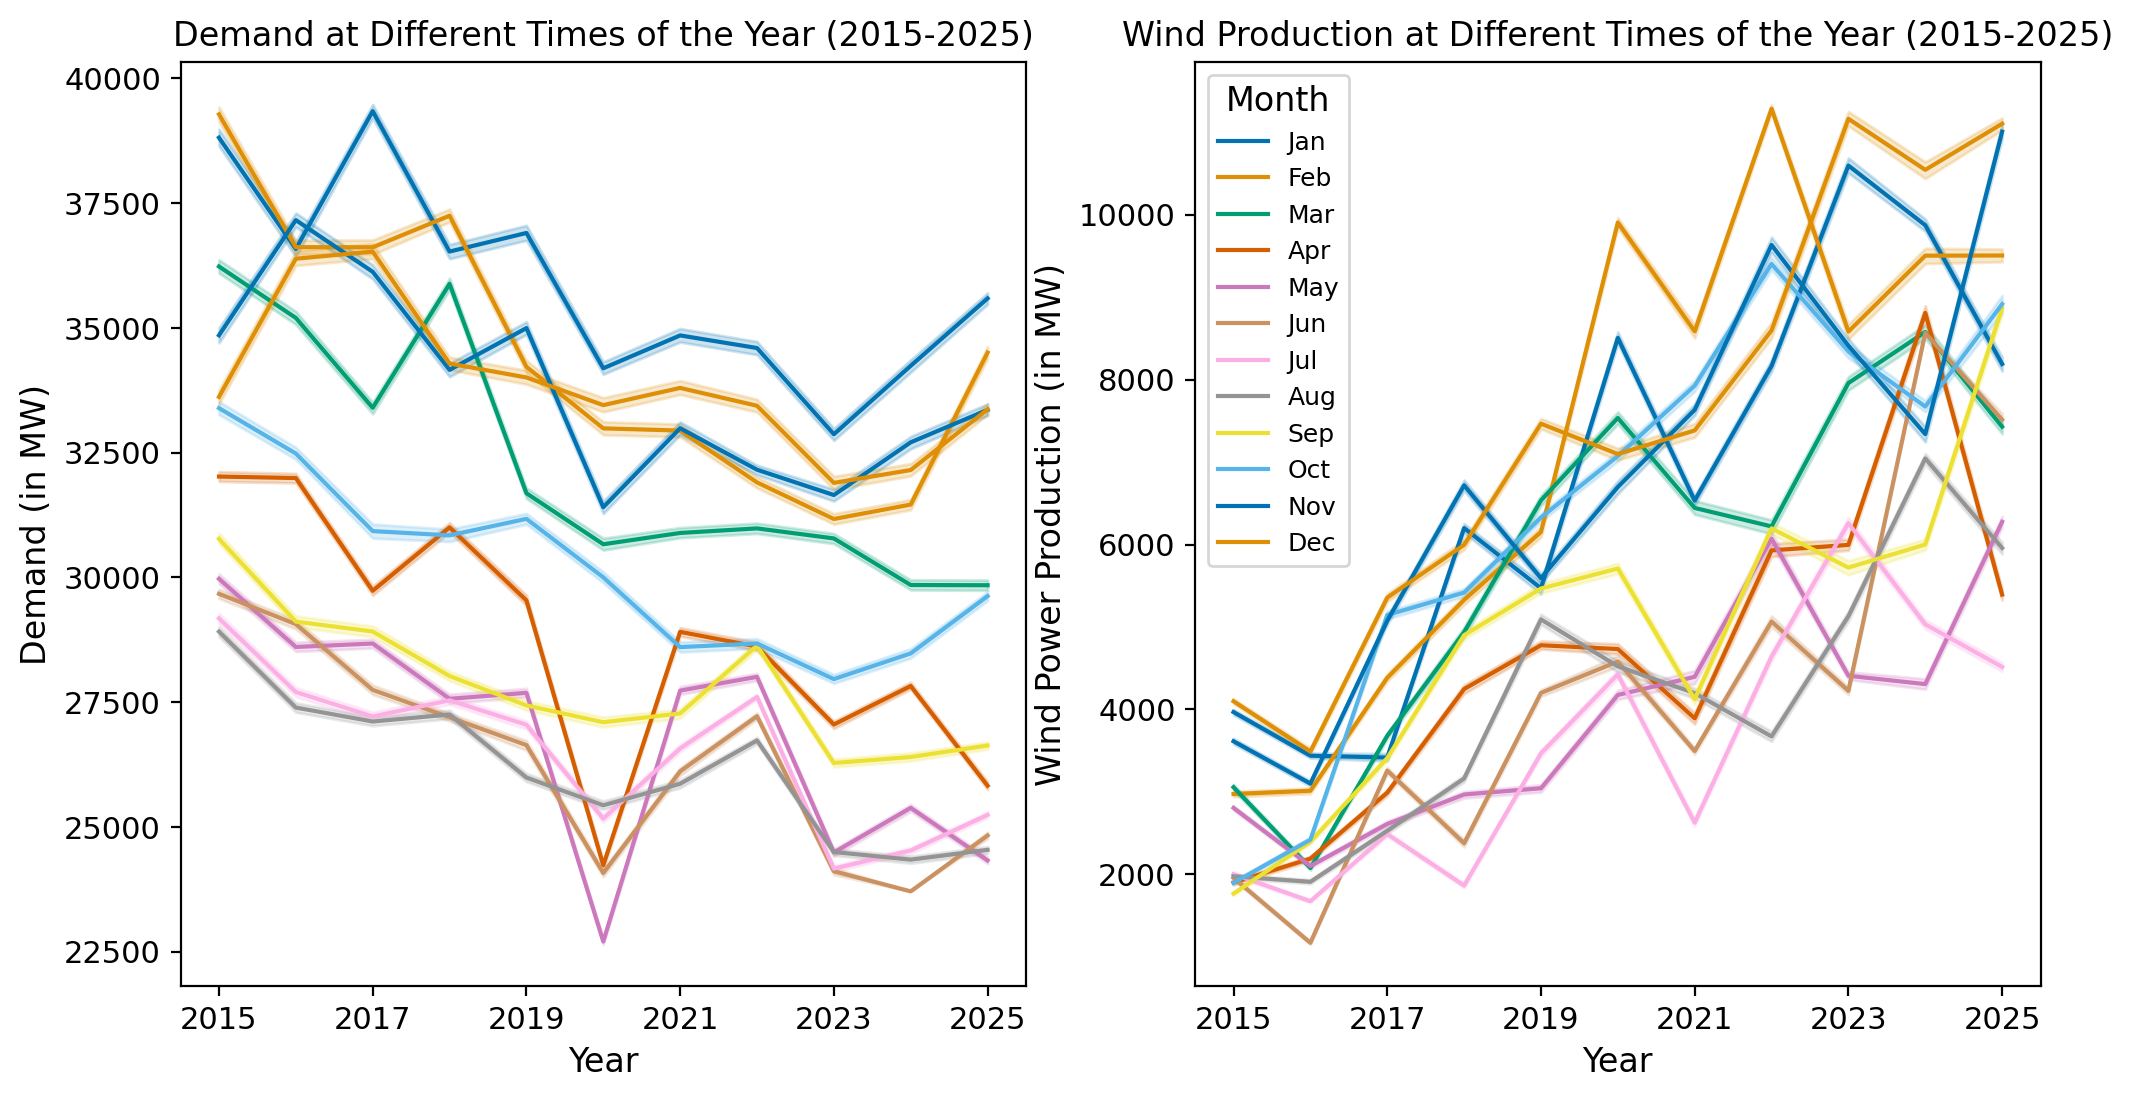

In [11]:
month_order=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig,axes=plt.subplots(1,2,figsize=(12,6))
sns.lineplot(data=data,x="year",y="demand",hue="month_name",hue_order=month_order,palette="colorblind",ax=axes[0],legend=False)
axes[0].set_title("Demand at Different Times of the Year (2015-2025)",fontsize=12)
axes[0].set_xlabel("Year",fontsize=12)
axes[0].set_ylabel("Demand (in MW)",fontsize=12)
axes[0].set_xticks(range(2015,2026,2)) #Set x-ticks from 2015-2025 skipping every other year
axes[0].tick_params(axis='both', labelsize=11)

sns.lineplot(data=data,x="year",y="wind",hue="month_name",hue_order=month_order,palette="colorblind",ax=axes[1])
axes[1].set_title("Wind Production at Different Times of the Year (2015-2025)",fontsize=12)
axes[1].set_xlabel("Year",fontsize=12)
axes[1].set_ylabel("Wind Power Production (in MW)",fontsize=12)
axes[1].legend(title='Month', fontsize=9, title_fontsize=12)
axes[1].set_xticks(range(2015,2026,2));
axes[1].tick_params(axis='both', labelsize=11)


In [12]:
groups=data.groupby('year')
groups['year'].value_counts()

year
2015    104875
2016    104860
2017    105031
2018    104988
2019    104916
2020    105408
2021    105102
2022    105064
2023    105021
2024    105105
2025    103720
Name: count, dtype: int64

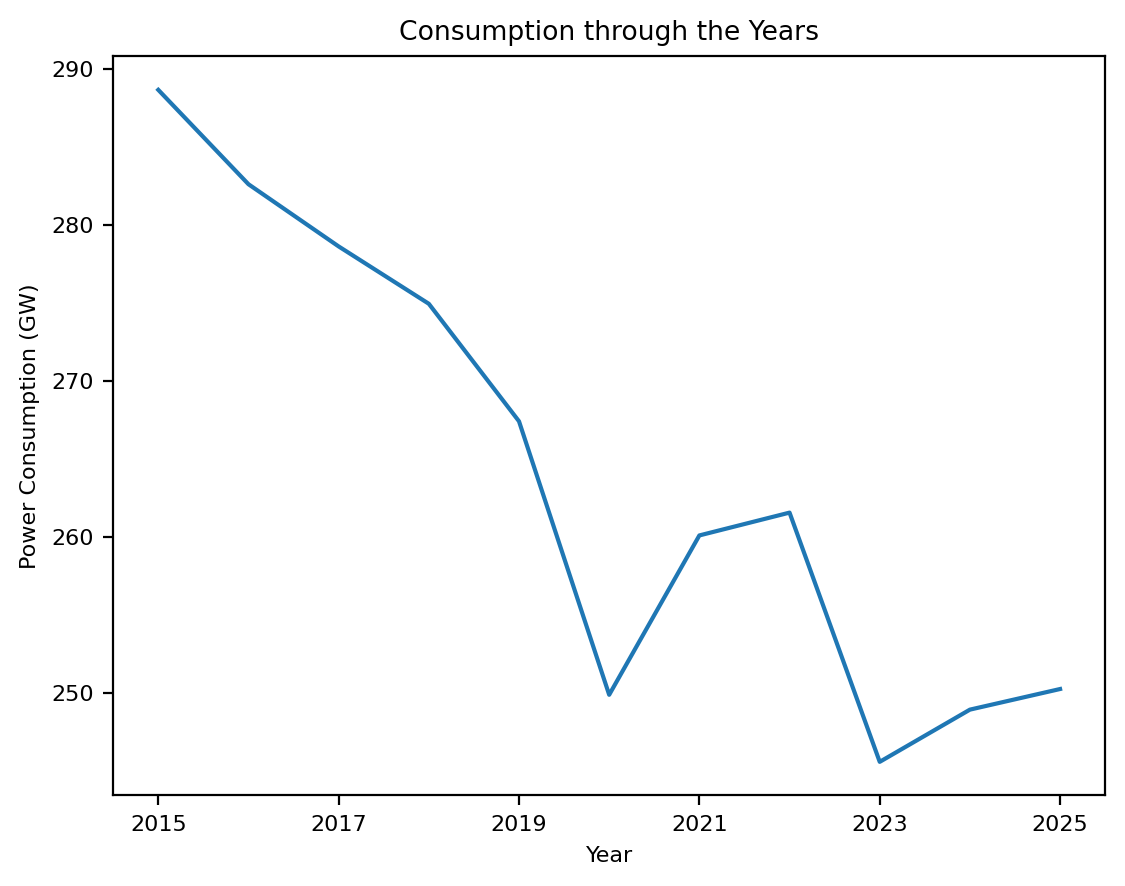

In [13]:
#Total consumption by Year

groups=data.groupby('year')
demand=groups['demand'].sum() * (5/60)/1e6
year=range(2015,2026)
plt.plot(year,demand)
plt.xlabel("Year")
plt.ylabel("Power Consumption (GW)")
plt.title("Consumption through the Years")
plt.xticks(ticks=range(2015,2026,2));


# 4 ***Data Communication and Analysis***

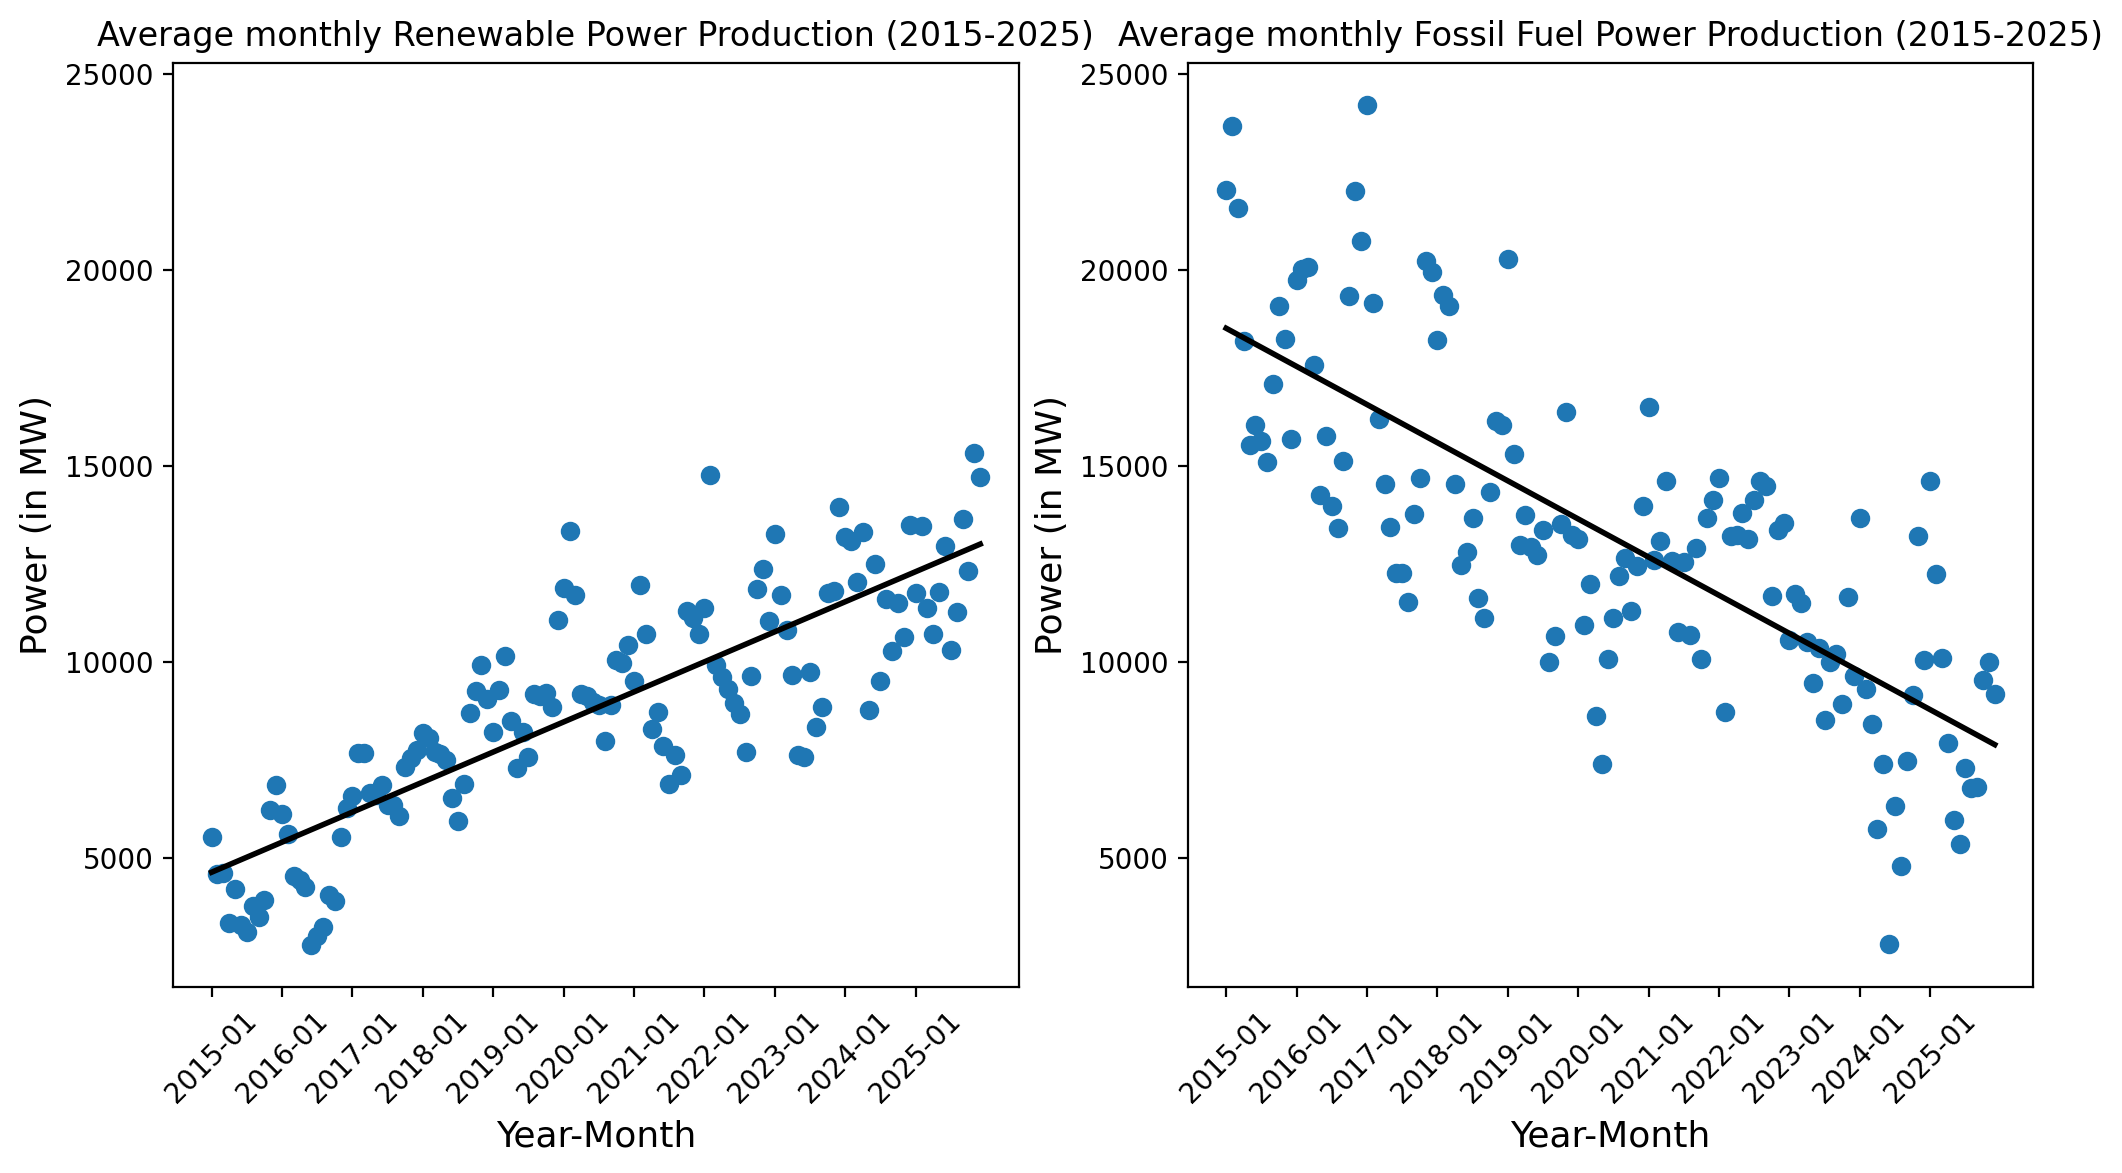

In [14]:
#Plot average monthly renewable & fossil power production from 2015-2025


y1=data.groupby(by='year-month')['renewable'].mean()
x1=y1.index
x1_numeric=range(len(x1))

y2=data.groupby(by='year-month')['fossil'].mean()
x2=y2.index
x2_numeric=range(len(x2))

fig=plt.figure(figsize=(12,6))
ax1,ax2=fig.subplots(1,2,sharey=True)

ax1.scatter(x=x1,y=y1)
z1=np.polyfit(x1_numeric,y1,1) #Returns least squares polynomial fit
ax1.plot(x1,np.poly1d(z1)(x1_numeric),color='black',linewidth=2) #Line of best fit 
ax1.set_title("Average monthly Renewable Power Production (2015-2025)",fontsize=12)
ax1.set_xlabel("Year-Month",fontsize=13)
ax1.set_ylabel("Power (in MW)",fontsize=13)
ax1.set_xticks(x1[::12])
ax1.tick_params(axis='x',rotation=45)
ax1.tick_params(axis='both',labelsize=10)


ax2.scatter(x=x2,y=y2)
z2=np.polyfit(x2_numeric,y2,1)
ax2.plot(x2,np.poly1d(z2)(x2_numeric),color='black',linewidth=2)
ax2.set_title("Average monthly Fossil Fuel Power Production (2015-2025)",fontsize=12)
ax2.set_xlabel("Year-Month",fontsize=13)
ax2.set_ylabel("Power (in MW)",fontsize=13)
ax2.set_xticks(x2[::12])
ax2.tick_params(labelleft=True)
ax2.tick_params(axis='x',rotation=45)
ax2.tick_params(axis='both',labelsize=10)

<Axes: >

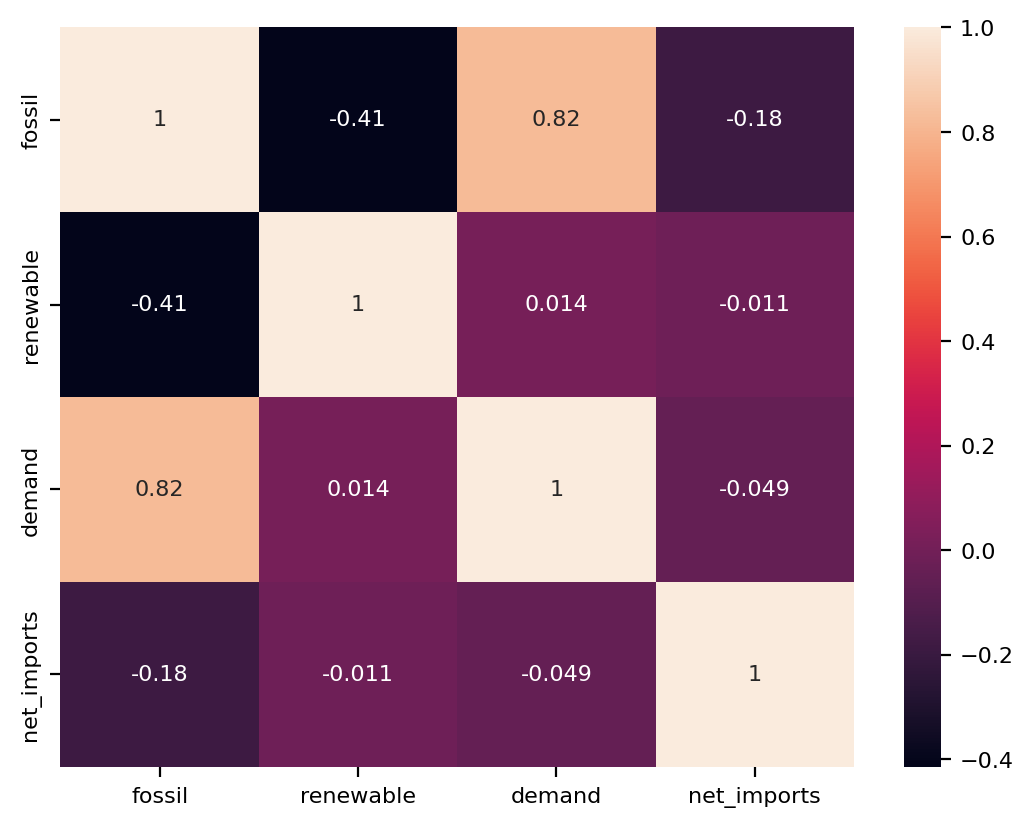

In [15]:
#Correlation matrix for all the variables concerned

sns.heatmap(data[["fossil","renewable","demand","net_imports"]].corr(),annot=True)


In [16]:
#Multiple regression model using OLS

daily_data=data.resample('D',on='timestamp').mean(numeric_only=True) #Aggregate daily
daily_data.insert(3,'month_name',daily_data.index.strftime('%b'))
daily_data['month_name']=pd.Categorical(daily_data['month_name'],categories=month_order,ordered=True) #Include monthly dummies with January as the baseline at 0
model_2=smf.ols(formula='fossil ~ solar + wind + hydro + biomass + demand + net_imports + month_name', data=daily_data).fit()
model_2.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 fossil   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     7133.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:00:57   Log-Likelihood:                -33444.
No. Observations:                4016   AIC:                         6.692e+04
Df Residuals:                    3998   BIC:                         6.704e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6526.0225    277.768    -23.495      0.000   -7070.602   -5981.443
month_name[T.Feb]  -125.4607     79.233     -1.583      0.113    -280.801      29.880
month_name[T.Mar]   112.8951     81.157      1.391      0.164     -46.218     272.009
month_name[T.Apr]  -180.0350     96.263     -1.870      0.062    -368.765       8.695
month_name[T.May]  -285.1394    106.272     -2.683      0.007    -493.491     -76.787
month_name[T.Jun]  -329.1356    109.864     -2.996      0.003    -544.531    -113.740
month_name[T.Jul]  -243.4964    108.377     -2.247      0.025    -455.977     -31.016
month_name[T.Aug]  -100.0147    107.156     -0.933      0.351    -310.100     110.070
month_name[T.Sep]  -143.7492    100.080     -1.436      0.151    -339.963      52.464
month_name[T.Oct]    18.9436     87.367      0.217      0.828    -152.344     190.231
month_name[T.Nov]  -143.4783     80.073     -1.792      0.073    -300.467      13.510
month_name[T.Dec]  -438.0969     78.561     -5.577      0.000    -592.119    -284.074
solar                 0.0456      0.023      1.962      0.050    3.69e-05       0.091
wind                 -0.9019      0.005   -166.806      0.000      -0.913      -0.891
hydro                -1.3406      0.105    -12.794      0.000      -1.546      -1.135
biomass              -0.4688      0.027    -17.429      0.000      -0.522      -0.416
demand                0.9101      0.007    137.576      0.000       0.897       0.923
net_imports          -0.8877      0.016    -55.144      0.000      -0.919      -0.856
==============================================================================
Omnibus:                       27.111   Durbin-Watson:                   0.248
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.025
Skew:                           0.187   Prob(JB):                     1.35e-06
Kurtosis:                       2.852   Cond. No.                     6.89e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.89e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

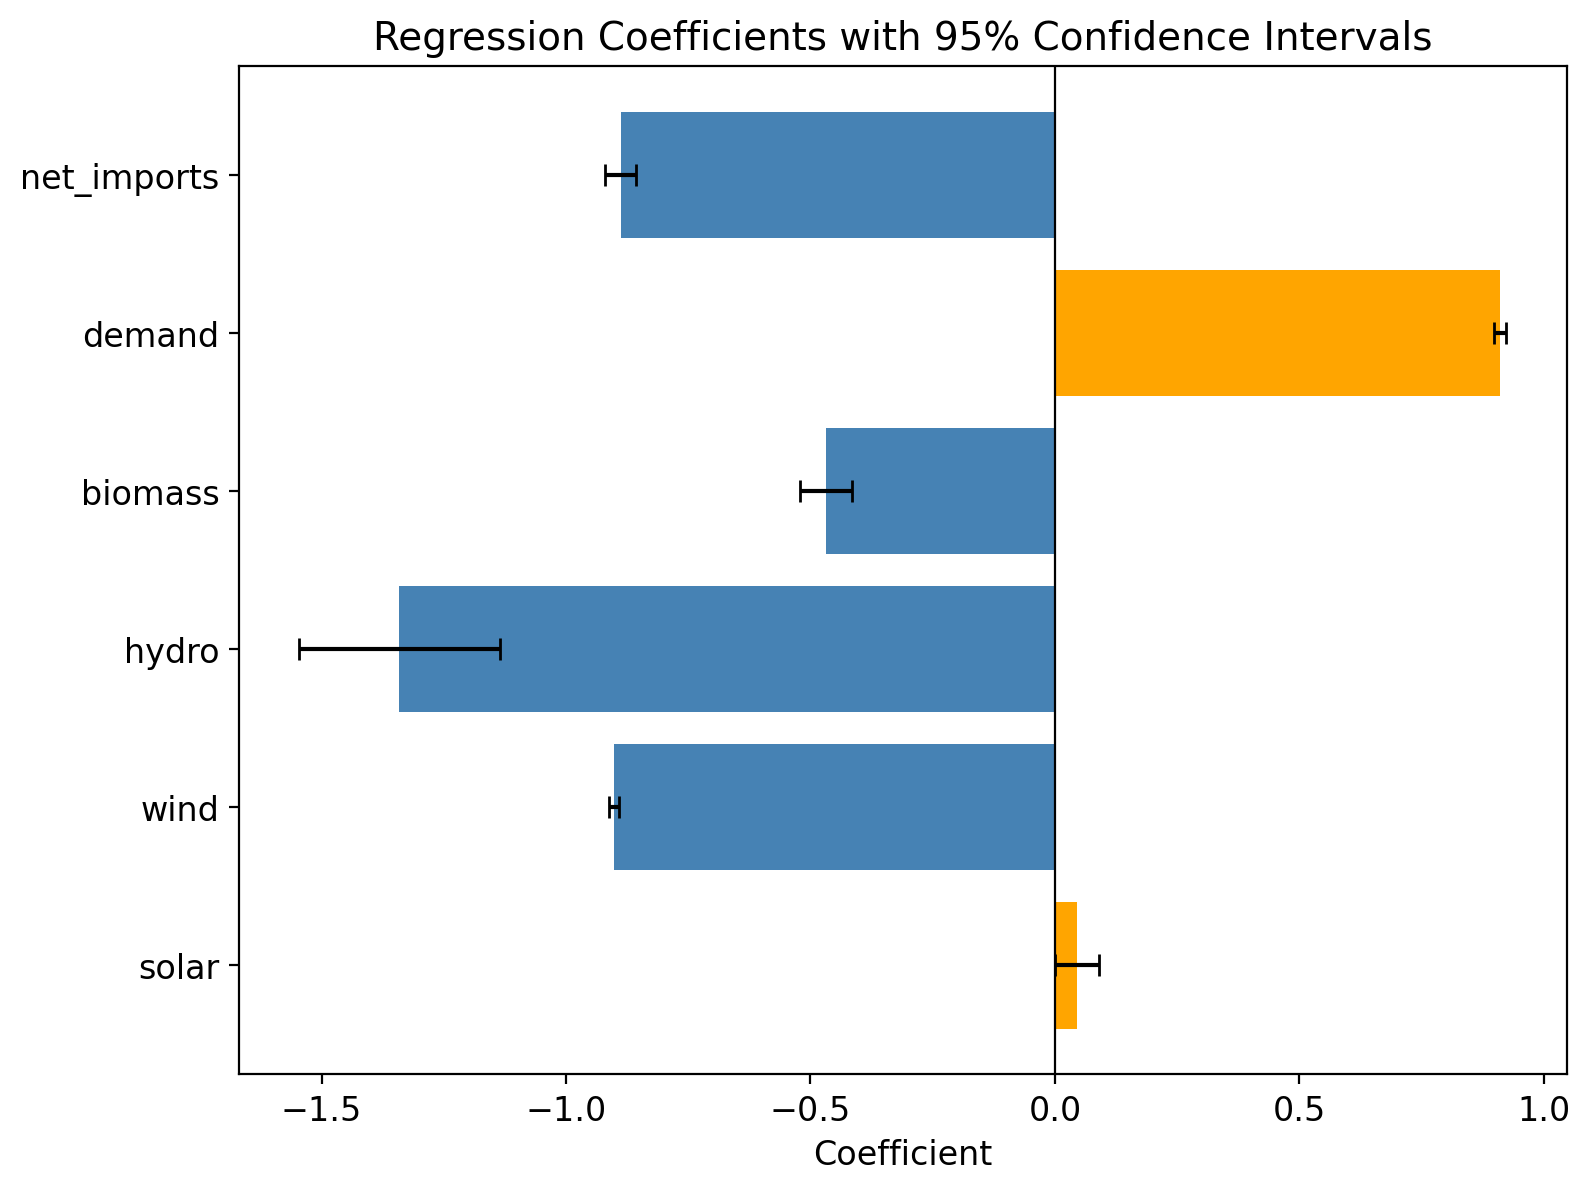

In [17]:
#Plot the regression coefficients continous variables 

fig,ax=plt.subplots(figsize=(8,6))
continuous=['solar','wind','hydro','biomass','demand','net_imports']
coefs=model_2.params[continuous]
conf=model_2.conf_int().loc[continuous] #Confidence intervals

ax.barh(continuous,coefs,xerr=[coefs-conf[0],conf[1]-coefs],capsize=4,color=['orange' if c > 0 else 'steelblue' for c in coefs]) #Blue when coefficient<0, red otherwise
ax.axvline(x=0,color='black',linewidth=0.8)
ax.set_xlabel('Coefficient',fontsize=12)
ax.set_title('Regression Coefficients with 95% Confidence Intervals',fontsize=14)
ax.tick_params(axis='both',labelsize=12)
plt.tight_layout()
plt.show()

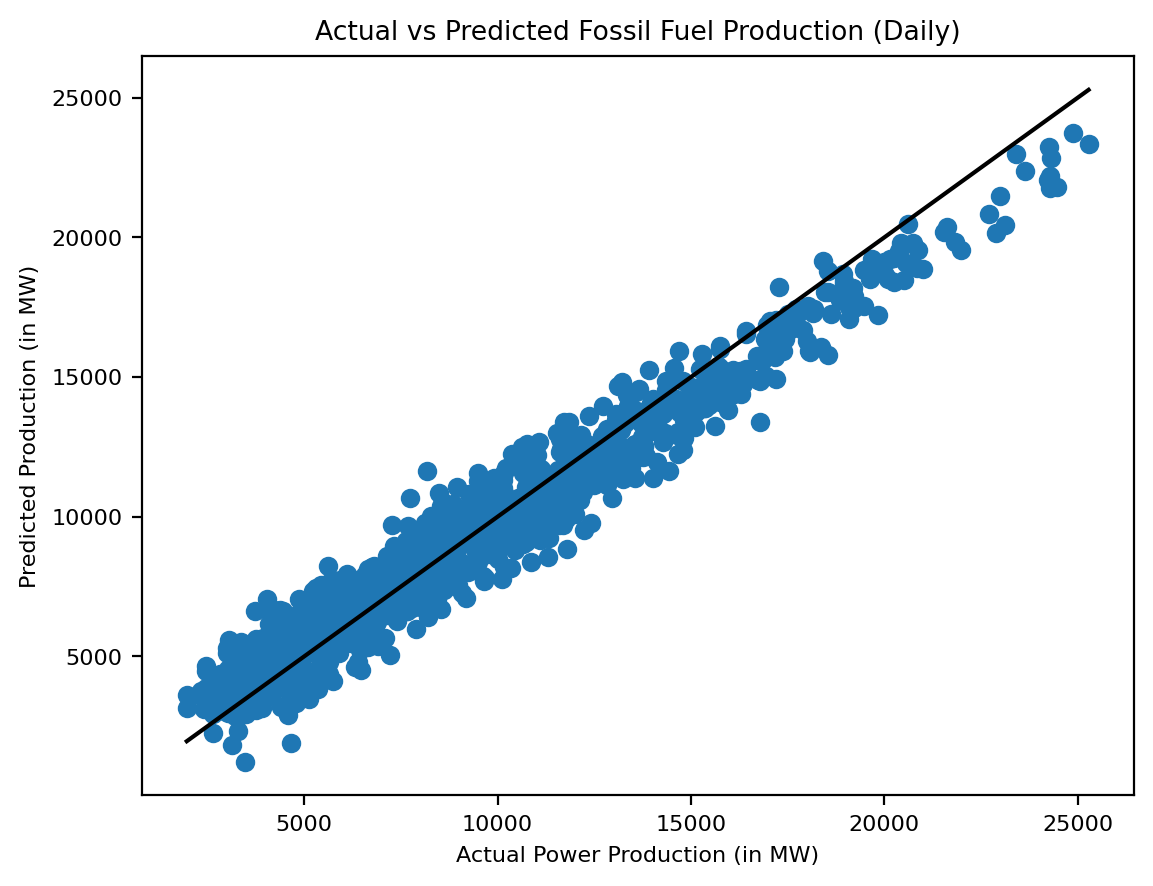

In [18]:
#Plot actual vs predicted  data to see how well the model fits

test_data=daily_data[daily_data['year']>2022] #Test data with year>2022 for 70-30 spllit
predictions=model_2.predict(test_data)
actual=test_data['fossil']

plt.scatter(actual,predictions)
plt.xlabel("Actual Power Production (in MW)")
plt.ylabel("Predicted Production (in MW)")
plt.title("Actual vs Predicted Fossil Fuel Production (Daily)")
plt.plot([actual.min(),actual.max()],[actual.min(),actual.max()],color='black')
plt.show()
